<a href="https://colab.research.google.com/github/YuriArduino/Estudos_Artificial_Intelligence/blob/main/Aprendizado_supervisionado/Machine_Learning_Classifica%C3%A7%C3%A3o_com_SKLearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primeira Classificação com Scikit-Learn
## Roteando tarefas entre Nisaba e Synnoia

Em vez de utilizar exemplos genéricos  vamos trabalhar com um cenário inspirado na arquitetura que estou desenvolvendo.

A ideia é simples:

Tenho dois agentes com funções diferentes.

- **Nisaba** → reflexão, raciocínio, síntese conceitual.
- **Synnoia** → execução, automação e processamento operacional.

O objetivo será ensinar um modelo de Machine Learning a decidir para qual agente uma tarefa deve ser enviada.

Em termos de IA, isso é um problema clássico de **classificação supervisionada**.

O modelo observará algumas características da tarefa e tentará prever qual agente deve recebê-la.

## Representando uma tarefa como dados

Uma máquina não entende conceitos como:

> "Esta tarefa parece reflexiva."

Ela entende apenas números.

Por isso precisamos transformar cada tarefa em características mensuráveis.

Neste exemplo utilizaremos:

1. Complexidade conceitual
2. Urgência operacional
3. Nível de automação possível

Cada característica será representada por um valor de 0 a 10.

Quanto maior o valor:

- Complexidade → mais raciocínio é necessário.
- Urgência → mais rapidez é exigida.
- Automação → mais facilmente a tarefa pode ser executada automaticamente.

Agora vamos criar alguns exemplos para ensinar o modelo.

In [55]:
#tarefa = [complexida, urgência,automação]

tarefa1 = [9, 2, 1] # 1 = Nisaba
tarefa2 = [8, 3, 2] # 1 = Nisaba
tarefa3 = [7, 2, 1] # 1 = Nisaba

tarefa4 = [2, 9, 8] # 0 = Synnoia
tarefa5 = [1, 8, 9] # 0 = Synnoia
tarefa6 = [3, 7, 7] # 0 = Synnoia

dados = [
    tarefa1,
    tarefa2,
    tarefa3,
    tarefa4,
    tarefa5,
    tarefa6
]

# 1 = Nisaba
# 0 = Synnoia

classes = [1, 1, 1, 0, 0, 0]

## O que são os rótulos (labels)?

Além das características, precisamos informar ao algoritmo qual é a resposta correta para cada exemplo.

Essas respostas são chamadas de:

- Classes
- Labels
- Rótulos

Neste conjunto de treinamento:

- 1 significa Nisaba
- 0 significa Synnoia

Durante o treinamento, o algoritmo tentará descobrir padrões que relacionam as características da tarefa ao agente mais adequado.

## Treinando o modelo

Agora utilizaremos o algoritmo LinearSVC.

SVC significa:

**Support Vector Classifier**

Ele tenta encontrar uma fronteira matemática capaz de separar as duas categorias.

Neste caso:

- tarefas mais reflexivas → Nisaba
- tarefas mais operacionais → Synnoia

O processo de treinamento consiste em apresentar os exemplos ao algoritmo para que ele aprenda essa separação.

In [56]:
from sklearn.svm import LinearSVC

modelo = LinearSVC()

modelo.fit(dados, classes)

LinearSVC()

## Primeira previsão

Depois do treinamento podemos apresentar uma tarefa inédita.

O modelo nunca viu essa tarefa antes.

Agora ele precisa responder:

> Esta tarefa deveria ir para Nisaba ou para Synnoia?

Esse é o momento em que verificamos se o aprendizado realmente ocorreu.

In [57]:
#1.Nisaba
#2.Synnoia

nova_tarefa = [8, 2, 7]

previsao = modelo.predict([nova_tarefa])

print(previsao)

[1]


## Interpretando o resultado

O valor retornado será:

- 1 → Nisaba
- 0 → Synnoia

Observe que o modelo não está "pensando".

Ele apenas identificou que a nova tarefa se parece mais com os exemplos de uma das categorias que recebeu durante o treinamento.

Machine Learning é essencialmente isso:

Encontrar padrões em exemplos anteriores para tomar decisões sobre casos novos.

## Criando um conjunto de testes

Treinar e testar usando exatamente os mesmos exemplos não é uma boa prática.

Precisamos criar tarefas novas para verificar se o modelo consegue generalizar o conhecimento adquirido.

Essas tarefas formam nosso conjunto de testes.

In [58]:
teste1 = [9, 1, 1]
teste2 = [2, 8, 8]
teste3 = [7, 3, 2]

testes = [
    teste1,
    teste2,
    teste3
]

previsoes = modelo.predict(testes)

print(previsoes)

[1 0 1]


## Definindo as respostas corretas

Para avaliar o desempenho do modelo precisamos saber qual seria a resposta correta para cada tarefa.

Essas respostas representam nosso gabarito.

Com elas poderemos comparar:

- O que o modelo previu.
- O que era esperado.

In [59]:
classes_reais = [1, 0, 1]

## Calculando a acurácia manualmente

A acurácia representa a porcentagem de acertos do modelo.

Fórmula:

Acurácia = Acertos / Total

Essa métrica é uma das mais utilizadas para problemas simples de classificação.

In [60]:
corretos = (previsoes == classes_reais).sum()

total = len(testes)

taxa_de_acerto = corretos / total * 100

print(f"Acurácia: {taxa_de_acerto:.2f}%")

Acurácia: 100.00%


## Utilizando a métrica oficial do Scikit-Learn

Embora seja importante compreender o cálculo manualmente, na prática utilizaremos as funções prontas da biblioteca.

A função `accuracy_score` realiza esse cálculo de forma segura e padronizada.

Além disso, ela serve de base para métricas mais avançadas que estudaremos futuramente.

In [61]:
from sklearn.metrics import accuracy_score

taxa_de_acerto = accuracy_score(classes_reais, previsoes) * 100

print(f"Acurácia: {taxa_de_acerto:.2f}%")

Acurácia: 100.00%


# Reflexão

O aspecto mais importante deste notebook não é o algoritmo.

É a transformação de uma decisão em uma representação numérica.

O processo seguido foi:

1. Definir um problema.
2. Transformar o problema em características.
3. Criar exemplos rotulados.
4. Treinar um modelo.
5. Testar o modelo.
6. Medir sua capacidade de generalização.

Em termos da arquitetura Nisaba:

A pergunta não era:

> "O que é uma tarefa?"

Mas sim:

> "Como representar uma tarefa para que uma máquina consiga decidir?"

Essa mudança de perspectiva é um dos fundamentos do Machine Learning.

#Teste, estratificação com dados

- stratified: gera previsões aleatórias com base na distribuição de classes dos dados de treinamento

In [62]:
uri_tracking = 'https://gist.githubusercontent.com/guilhermesilveira/b9dd8e4b62b9e22ebcb9c8e89c271de4/raw/c69ec4b708fba03c445397b6a361db4345c83d7a/tracking.csv'
uri_projetos = 'https://gist.githubusercontent.com/guilhermesilveira/12291c548acaf544596795709020e3db/raw/325bdef098bd9cbc2189215b7e32e22f437f29f3/projetos.csv'

In [63]:
import pandas as pd

lista_track = pd.read_csv(uri_tracking, sep=',')
lista_projetos = pd.read_csv(uri_projetos, sep=',')

In [64]:
print (lista_track.sample(5))
print()
print()
print("-----------------------------------------------------")
print()
print()
print(lista_projetos.sample(5))

    inicial  palestras  contato  comprou  patrocinio
90        1          0        1        1           0
58        1          0        1        1           0
32        0          0        1        0           0
61        0          1        0        0           0
13        0          0        1        0           0


-----------------------------------------------------


      nao_finalizado  horas_esperadas        preco
1284               0             34.0   387.000000
1426               1             32.0   218.000000
886                1             89.0  9610.000000
2326               0              0.0  2572.886587
365                1             49.0   474.000000


In [65]:
print(lista_track.shape)
print(lista_projetos.shape)

(99, 5)
(2457, 3)


In [66]:
x = lista_track[['inicial', 'palestras', 'contato', 'patrocinio']]
y = lista_track['comprou']

In [67]:
treino_x = x[:75]
treino_y = y[:75]

teste_x = x[75:]
teste_y = y[75:]

print(f"Treinaremos com {len(treino_x)} elementos e testaremos com {len(teste_x)} elementos")

Treinaremos com 75 elementos e testaremos com 24 elementos


In [68]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

modelo = LinearSVC()
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)


taxa_de_acerto = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {taxa_de_acerto:.2f}% ")

A acurácia foi de 95.83% 


##Usando a biblioteca para separar treino e teste

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

SEED = 777
treino_x, teste_x, treino_y, teste_y = train_test_split(x,y, random_state= SEED,stratify=y, test_size=0.25)

print(f"Treinaremos com {len(treino_x)} elementos e testaremos com {len(teste_x)} elementos")


modelo = LinearSVC()
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

taxa_de_acerto = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {taxa_de_acerto:.2f}% ")

Treinaremos com 74 elementos e testaremos com 25 elementos
A acurácia foi de 96.00% 


In [70]:
treino_y.value_counts()

,count
comprou,
0,49
1,25


In [71]:
teste_y.value_counts()

,count
comprou,
0,17
1,8


#Testando em duas dimensões

In [72]:
lista_projetos.sample()

,nao_finalizado,horas_esperadas,preco
1741,1,41.0,132.0


In [73]:
lista_projetos["finalizado"] = lista_projetos["nao_finalizado"].map({1: 0, 0: 1})
lista_projetos.head()

,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.000000,1
1,1,0.0,4325.293458,0
2,0,87.0,14205.000000,1
3,1,13.0,100.000000,0
4,0,2.0,202.000000,1


<Axes: xlabel='horas_esperadas', ylabel='preco'>

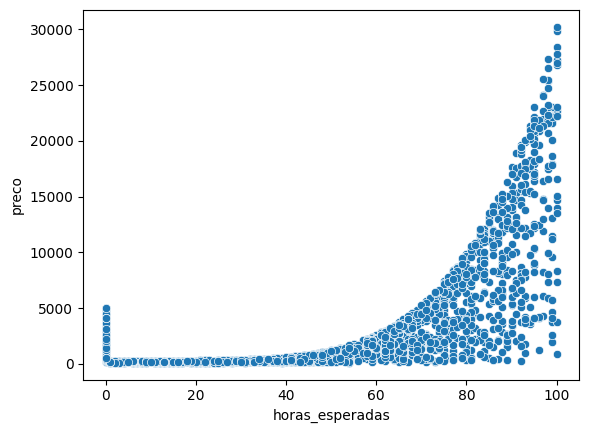

In [74]:
import seaborn as sns

sns.scatterplot(x="horas_esperadas", y="preco", data=lista_projetos)

<Axes: xlabel='horas_esperadas', ylabel='preco'>

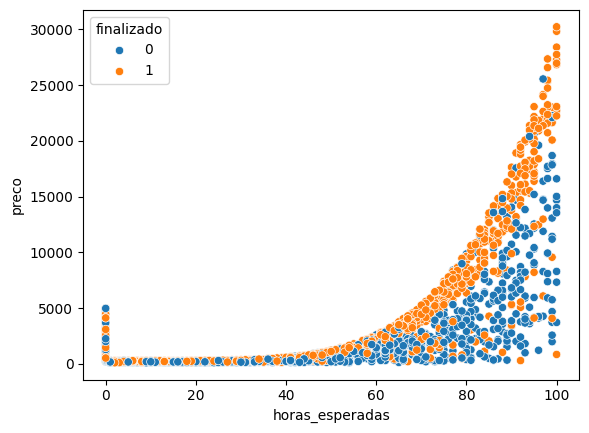

In [75]:
sns.scatterplot(x="horas_esperadas", y="preco", data=lista_projetos, hue = "finalizado")

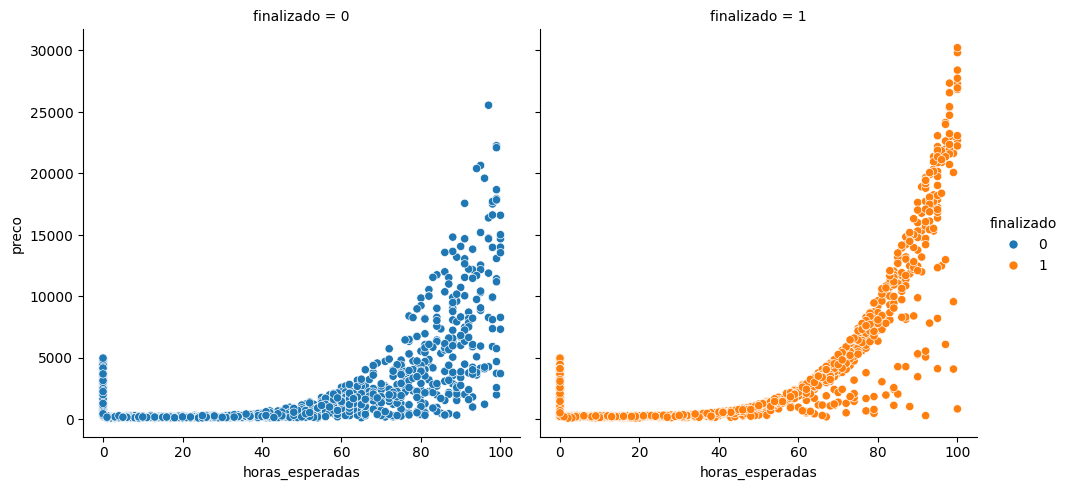

In [76]:
sns.relplot(x="horas_esperadas", y="preco", data=lista_projetos, hue = "finalizado",col="finalizado")

In [77]:
dados = lista_projetos.query("horas_esperadas > 0")
dados.sample()

,nao_finalizado,horas_esperadas,preco,finalizado
1430,1,35.0,140.0,0


In [78]:
x = dados[["horas_esperadas", "preco"]]
y = dados["finalizado"]

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

SEED = 777
treino_x, teste_x, treino_y, teste_y = train_test_split(
    x,
    y,
    random_state= SEED,
    stratify=y,
    )

print(f"Treinaremos com {len(treino_x)} elementos e testaremos com {len(teste_x)} elementos")


modelo = LinearSVC()
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

taxa_de_acerto = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {taxa_de_acerto:.2f}% ")

Treinaremos com 1617 elementos e testaremos com 540 elementos
A acurácia foi de 58.15% 


In [80]:
previsoes_de_base = teste_y.sum() / len(teste_y) *100
print(f"A acurácia do modelo de base foi de {previsoes_de_base:.2f}% ")

A acurácia do modelo de base foi de 52.59% 


In [81]:
x_min = teste_x.horas_esperadas.min()
x_max = teste_x.horas_esperadas.max()

y_min = teste_x.preco.min()
y_max = teste_x.preco.max()

print(f"O eixo x vai de {x_min} a {x_max}")
print(f"O eixo y vai de {y_min} a {y_max}")

O eixo x vai de 1.0 a 100.0
O eixo y vai de 100.0 a 27343.0


In [82]:
import numpy as np

pixel = 100

eixo_x =np.arange(x_min, x_max, (x_max - x_min) / pixel)
eixo_y =np.arange(y_min, y_max, (y_max - y_min) / pixel)
print(eixo_x)
print(eixo_y)

[ 1.    1.99  2.98  3.97  4.96  5.95  6.94  7.93  8.92  9.91 10.9  11.89
 12.88 13.87 14.86 15.85 16.84 17.83 18.82 19.81 20.8  21.79 22.78 23.77
 24.76 25.75 26.74 27.73 28.72 29.71 30.7  31.69 32.68 33.67 34.66 35.65
 36.64 37.63 38.62 39.61 40.6  41.59 42.58 43.57 44.56 45.55 46.54 47.53
 48.52 49.51 50.5  51.49 52.48 53.47 54.46 55.45 56.44 57.43 58.42 59.41
 60.4  61.39 62.38 63.37 64.36 65.35 66.34 67.33 68.32 69.31 70.3  71.29
 72.28 73.27 74.26 75.25 76.24 77.23 78.22 79.21 80.2  81.19 82.18 83.17
 84.16 85.15 86.14 87.13 88.12 89.11 90.1  91.09 92.08 93.07 94.06 95.05
 96.04 97.03 98.02 99.01]
[  100.     372.43   644.86   917.29  1189.72  1462.15  1734.58  2007.01
  2279.44  2551.87  2824.3   3096.73  3369.16  3641.59  3914.02  4186.45
  4458.88  4731.31  5003.74  5276.17  5548.6   5821.03  6093.46  6365.89
  6638.32  6910.75  7183.18  7455.61  7728.04  8000.47  8272.9   8545.33
  8817.76  9090.19  9362.62  9635.05  9907.48 10179.91 10452.34 10724.77
 10997.2  11269.63 11542.

In [83]:
xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]
pontos

array([[1.000000e+00, 1.000000e+02],
       [1.990000e+00, 1.000000e+02],
       [2.980000e+00, 1.000000e+02],
       ...,
       [9.703000e+01, 2.707057e+04],
       [9.802000e+01, 2.707057e+04],
       [9.901000e+01, 2.707057e+04]])

In [84]:
Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)
Z

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

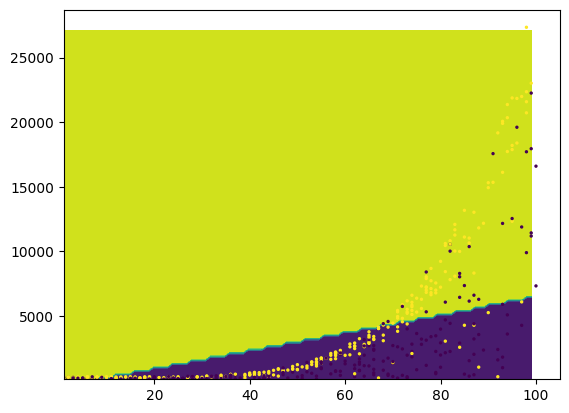

In [85]:
import matplotlib.pyplot as plt

plt.contourf(xx, yy, Z)
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c=teste_y, s=2)


##Limitação do Linear SVC:

*   O modelo cria uma reta para separar as classes (finalizados vs não-finalizados)
*   Quando os dados têm um padrão curvo, a reta não consegue acompanhar essa curvatura
*   Resultado: muitos projetos não-finalizados são classificados incorretamente como finalizados

Por que isso importa:

*   Uma acurácia de 62% não é suficiente se o modelo está errando sistematicamente em uma região específica dos dados
*   Precisamos de um modelo que consiga aprender padrões mais complexos



`Precisamos então de um modelo capaz de aprender esses padrões mais complexos e não-óbvios dos dados. O Linear SVC é muito simples para capturar essa nuança.`

In [86]:
# SVC NÃO-LINEAR

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

SEED = 777
treino_x, teste_x, treino_y, teste_y = train_test_split(
    x,
    y,
    random_state= SEED,
    stratify=y,
    )

print(f"Treinaremos com {len(treino_x)} elementos e testaremos com {len(teste_x)} elementos")


modelo = SVC(gamma= 'auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

taxa_de_acerto = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {taxa_de_acerto:.2f}% ")

Treinaremos com 1617 elementos e testaremos com 540 elementos
A acurácia foi de 60.37% 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


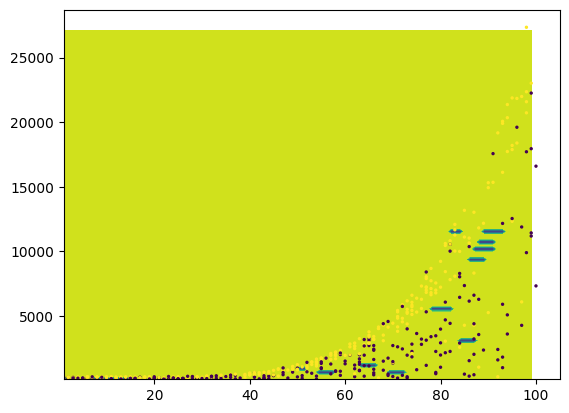

In [88]:
x_min = teste_x.horas_esperadas.min()
x_max = teste_x.horas_esperadas.max()

y_min = teste_x.preco.min()
y_max = teste_x.preco.max()



pixel = 100

eixo_x =np.arange(x_min, x_max, (x_max - x_min) / pixel)
eixo_y =np.arange(y_min, y_max, (y_max - y_min) / pixel)


xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c=teste_y, s=2)

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

SEED = 777
raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(
    x,
    y,
    random_state= SEED,
    stratify=y,
    )

print(f"Treinaremos com {len(raw_treino_x)} elementos e testaremos com {len(raw_teste_x)} elementos")

#Análise
scaler = StandardScaler()
scaler.fit(raw_treino_x)
#Aplicação
treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)


modelo = SVC(gamma= 'auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

taxa_de_acerto = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {taxa_de_acerto:.2f}% ")

Treinaremos com 1617 elementos e testaremos com 540 elementos
A acurácia foi de 70.00% 


In [90]:
#Alteração com o sclaer o resultado é uma lista com duas colunas

teste_x

array([[-1.21472036, -0.5856963 ],
       [ 1.0358298 , -0.04941397],
       [ 0.86000557, -0.45215793],
       ...,
       [-1.56636882, -0.56711705],
       [ 1.45780796,  3.09551127],
       [-1.28505005, -0.56460111]])

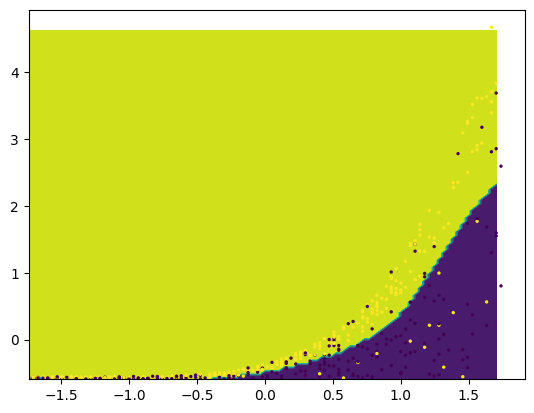

In [91]:
data_col1 = teste_x[:, 0]
data_col2 = teste_x[:, 1]

x_min = data_col1.min()
x_max = data_col1.max()

y_min = data_col2.min()
y_max = data_col2.max()



pixel = 100

eixo_x =np.arange(x_min, x_max, (x_max - x_min) / pixel)
eixo_y =np.arange(y_min, y_max, (y_max - y_min) / pixel)


xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(data_col1,data_col2, c=teste_y, s=2)

In [92]:
import pandas as pd

dados = pd.read_csv("https://gist.githubusercontent.com/guilhermesilveira/dd7ba8142321c2c8aaa0ddd6c8862fcc/raw/e694a9b43bae4d52b6c990a5654a193c3f870750/precos.csv")
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido
0,21801,2000,30941.02,1
1,7843,1998,40557.96,1
2,7109,2006,89627.50,0
3,26823,2015,95276.14,0
4,7935,2014,117384.68,1


In [93]:
dados["km_por_ano"] = dados["milhas_por_ano"] * 160934
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano
0,21801,2000,30941.02,1,3508522134
1,7843,1998,40557.96,1,1262205362
2,7109,2006,89627.50,0,1144079806
3,26823,2015,95276.14,0,4316732682
4,7935,2014,117384.68,1,1277011290


In [94]:
from datetime import datetime


dados["anos_de_uso"] =datetime.today().year - dados["ano_do_modelo"]
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano,anos_de_uso
0,21801,2000,30941.02,1,3508522134,26
1,7843,1998,40557.96,1,1262205362,28
2,7109,2006,89627.50,0,1144079806,20
3,26823,2015,95276.14,0,4316732682,11
4,7935,2014,117384.68,1,1277011290,12


In [95]:
dados.drop(["milhas_por_ano", "ano_do_modelo"], axis=1, inplace=True)
dados.head()

,preco,vendido,km_por_ano,anos_de_uso
0,30941.02,1,3508522134,26
1,40557.96,1,1262205362,28
2,89627.50,0,1144079806,20
3,95276.14,0,4316732682,11
4,117384.68,1,1277011290,12


In [96]:
x = dados[["preco","anos_de_uso","km_por_ano"]]
y = dados["vendido"]

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

SEED = 777
raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(
    x,
    y,
    random_state= SEED,
    stratify=y,
    )

print(f"Treinaremos com {len(raw_treino_x)} elementos e testaremos com {len(raw_teste_x)} elementos")

#Análise
scaler = StandardScaler()
scaler.fit(raw_treino_x)
#Aplicação
treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

# Dummy Classifier
classificador_dummy = DummyClassifier()
classificador_dummy.fit(treino_x, treino_y)
previsoes_dummy = classificador_dummy.predict(teste_x)
taxa_de_acerto_dummy = accuracy_score(teste_y, previsoes_dummy) * 100
print(f"A acurácia do DummyClassifier foi de {taxa_de_acerto_dummy:.2f}% ")

# SVC Model
modelo = SVC(gamma= 'auto')
modelo.fit(treino_x, treino_y)
previsoes_svc = modelo.predict(teste_x)

taxa_de_acerto_svc = accuracy_score(teste_y, previsoes_svc) * 100
print(f"A acurácia do SVC foi de {taxa_de_acerto_svc:.2f}% ")

Treinaremos com 7500 elementos e testaremos com 2500 elementos
A acurácia do DummyClassifier foi de 58.00% 
A acurácia do SVC foi de 77.00% 


In [105]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

SEED = 777
raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(
    x,
    y,
    random_state= SEED,
    stratify=y,
    )

print(f"Treinaremos com {len(raw_treino_x)} elementos e testaremos com {len(raw_teste_x)} elementos")

#Análise
scaler = StandardScaler()
scaler.fit(raw_treino_x)
#Aplicação
treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

# Dummy Classifier
classificador_dummy = DummyClassifier(strategy='stratified')
classificador_dummy.fit(treino_x, treino_y)
previsoes_dummy = classificador_dummy.predict(teste_x)
taxa_de_acerto_dummy = accuracy_score(teste_y, previsoes_dummy) * 100
print(f"A acurácia do DummyClassifier foi de {taxa_de_acerto_dummy:.2f}% ")

# SVC Model
modelo = SVC(gamma= 'auto')
modelo.fit(treino_x, treino_y)
previsoes_svc = modelo.predict(teste_x)

taxa_de_acerto_svc = accuracy_score(teste_y, previsoes_svc) * 100
print(f"A acurácia do SVC foi de {taxa_de_acerto_svc:.2f}% ")

Treinaremos com 7500 elementos e testaremos com 2500 elementos
A acurácia do DummyClassifier foi de 52.60% 
A acurácia do SVC foi de 77.00% 


#Decision Tree

##Divide dados em ramificações baseadas em regras simples para prever valores numéricos. É fácil de interpretar porque permite ver claramente como cada decisão foi tomada.

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

SEED = 777
raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(
    x,
    y,
    random_state= SEED,
    stratify=y,
    )

print(f"Treinaremos com {len(raw_treino_x)} elementos e testaremos com {len(raw_teste_x)} elementos")

#Análise
scaler = StandardScaler()
scaler.fit(raw_treino_x)
#Aplicação
treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

# Dummy Classifier
classificador_dummy = DummyClassifier(strategy='stratified')
classificador_dummy.fit(treino_x, treino_y)
previsoes_dummy = classificador_dummy.predict(teste_x)
taxa_de_acerto_dummy = accuracy_score(teste_y, previsoes_dummy) * 100
print(f"A acurácia do DummyClassifier foi de {taxa_de_acerto_dummy:.2f}% ")

# DecisionTree Model
modelo = DecisionTreeClassifier(max_depth=7)
modelo.fit(treino_x, treino_y)
previsoes_DecisionTreeClassifier = modelo.predict(teste_x)

taxa_de_acerto_DecisionTreeClassifier = accuracy_score(teste_y, previsoes_DecisionTreeClassifier) * 100
print(f"A acurácia do DecisionTreeClassifier foi de {taxa_de_acerto_DecisionTreeClassifier:.2f}% ")

Treinaremos com 7500 elementos e testaremos com 2500 elementos
A acurácia do DummyClassifier foi de 51.16% 
A acurácia do DecisionTreeClassifier foi de 78.72% 


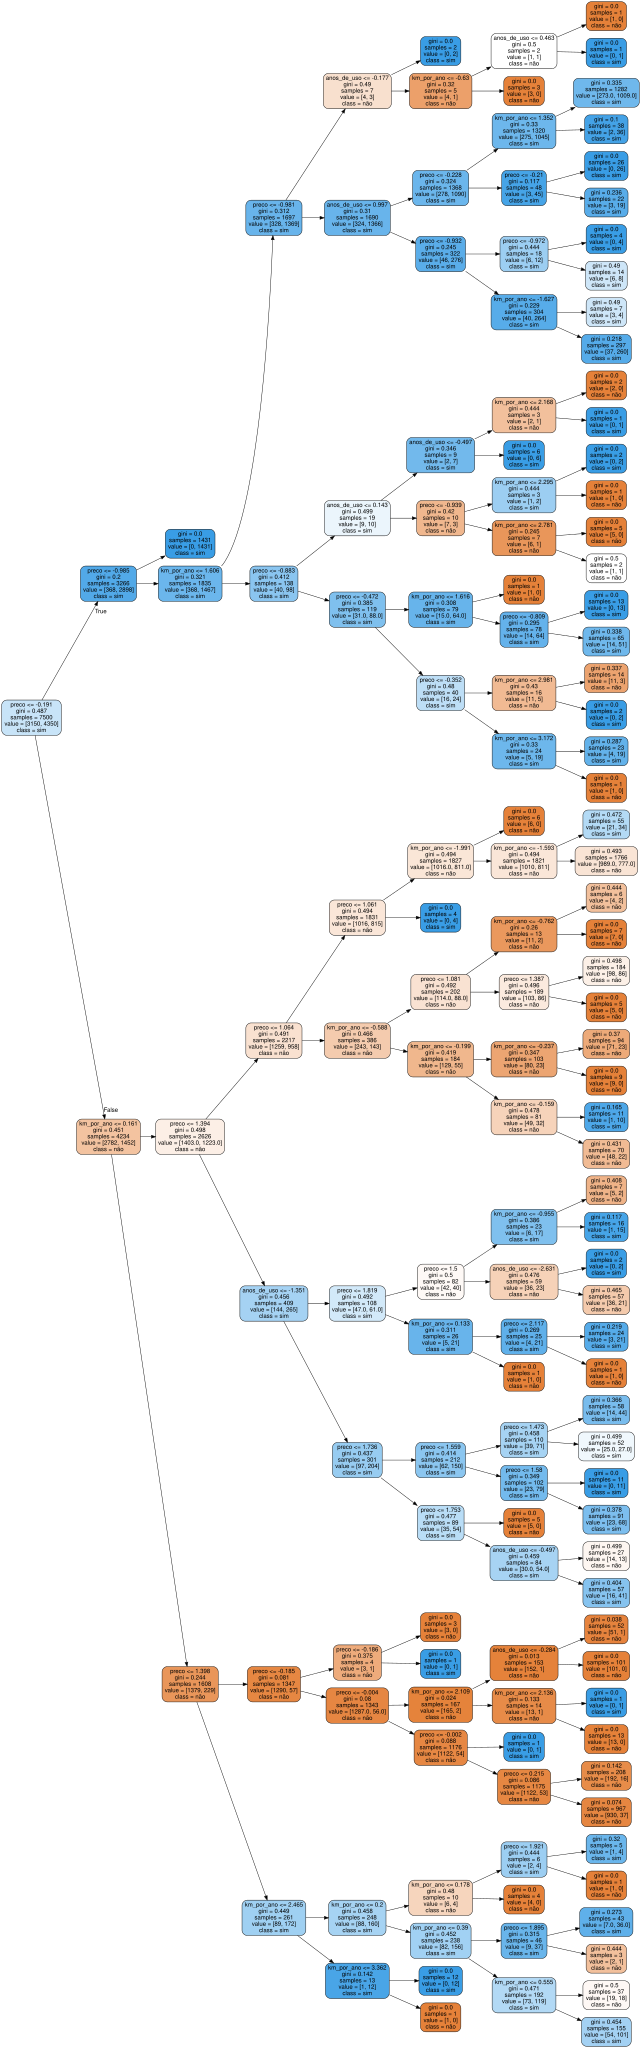

In [122]:
from sklearn.tree import export_graphviz
import graphviz

estrutura = export_graphviz(
    modelo,
    filled=True,
    rounded=True,
    feature_names=x.columns,
    class_names=["não", "sim"]
    )

# Add graph attributes directly to the DOT string, removing 'size'
estrutura = 'digraph Tree { graph [rankdir="LR"]; ' + estrutura[estrutura.find('{') + 1:]
grafico = graphviz.Source(estrutura, format='svg')
grafico

In [123]:
graph_filename = 'decision_tree_graph'
grafico.render(filename=graph_filename, view=False, format='svg', cleanup=True)
print(f"The decision tree graph has been saved as '{graph_filename}.svg' in your Colab environment.")

The decision tree graph has been saved as 'decision_tree_graph.svg' in your Colab environment.
